# GRA tests


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
class AdamProposed(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super(AdamProposed, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                
                # We work with the gradient
                grad = p.grad
                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    # Exponential moving average of gradient values
                    state['exp_avg'] = torch.zeros_like(p, memory_format=torch.preserve_format)
                    # Exponential moving average of PROPOSED squared values
                    state['exp_avg_sq'] = torch.zeros_like(p, memory_format=torch.preserve_format)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']

                state['step'] += 1

                # 1. Update First Moment (m_t)
                # m_t = beta1 * m_{t-1} + (1 - beta1) * g_t
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)

                # -----------------------------------------------------------
                # YOUR PROPOSAL
                # Standard Adam: v_t = beta2 * v_{t-1} + (1 - beta2) * g_t^2
                # Your Modified: v_t = beta2 * v_{t-1} + (1 - beta2) * m_t^2
                # -----------------------------------------------------------
                
                # Note: We use 'exp_avg' (m_t) here, not 'grad' (g_t)
                # exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                exp_avg_sq.mul_(beta2).addcmul_(exp_avg, exp_avg, value=1 - beta2)

                # Bias Correction
                # We must correct bias for both because they are initialized at 0
                # bias_correction1 = 1 - beta1 ** state['step']
                # bias_correction2 = 1 - beta2 ** state['step']
                bias_correction1 = 1
                bias_correction2 = 1

                step_size = group['lr'] / bias_correction1

                # Denominator computation
                denom = (exp_avg_sq.sqrt() / np.sqrt(bias_correction2)).add_(group['eps'])

                # Update parameters
                p.addcdiv_(exp_avg, denom, value=-step_size)

        return loss

In [3]:
# ---------------------------------------------------------
# Test Harness
# ---------------------------------------------------------

def run_experiment(optimizer_class, noise_std=0.0, iterations=10_000):
    # Simple Quadratic Bowl: f(x) = x^2 + 10y^2
    # Global minimum is at (0,0)
    params = torch.tensor([2.0, 2.0], requires_grad=True)
    opt = optimizer_class([params], lr=0.001)

    trajectory = []
    
    for i in range(iterations):
        opt.zero_grad()
        
        # Loss function
        x, y = params[0], params[1]
        loss = x**2 + 10*y**2
        loss.backward()
        
        # INJECT NOISE into gradients to test robustness
        if noise_std > 0:
            with torch.no_grad():
                params.grad += torch.randn_like(params.grad) * noise_std
        
        opt.step()
        trajectory.append(loss.item())
        
    return trajectory

In [4]:
# Run Comparison
torch.manual_seed(42)

# Case 1: Low Noise (Approximating pure gradients)
loss_std_clean = run_experiment(torch.optim.Adam, noise_std=0.1)
loss_prop_clean = run_experiment(AdamProposed, noise_std=0.1)

# Case 2: High Noise (Where variance blindness hurts)
loss_std_noisy = run_experiment(torch.optim.Adam, noise_std=4.0)
loss_prop_noisy = run_experiment(AdamProposed, noise_std=4.0)

In [5]:
# Visualization code (Run this locally to see plot)
print(f"{'Iteration':<10} | {'Adam (Clean)':<15} | {'Proposed (Clean)':<15} | {'Adam (Noisy)':<15} | {'Proposed (Noisy)':<15}")
print("-" * 85)
# for i in [0, 10, 50, 100, 199, 500, 999]:
for i in [0, 100, 1000, 9999]:
    print(f"{i:<10} | {loss_std_clean[i]:<15.4f} | {loss_prop_clean[i]:<15.4f} | {loss_std_noisy[i]:<15.4f} | {loss_prop_noisy[i]:<15.4f}")

Iteration  | Adam (Clean)    | Proposed (Clean) | Adam (Noisy)    | Proposed (Noisy)

-------------------------------------------------------------------------------------

0          | 44.0000         | 44.0000         | 44.0000         | 44.0000

100        | 39.7472         | 18.6564         | 39.9182         | 18.6725

1000       | 13.7802         | 0.9124          | 14.5590         | 0.9519

9999       | 0.0001          | 0.0000          | 0.0017          | 0.0169

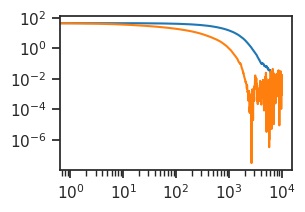

In [6]:
plot(loss_std_noisy)
plot(loss_prop_noisy)
plt.xscale('log')
plt.yscale('log')

In [7]:
# ---------------------------------------------------------
# 2. Model & Helper Functions
# ---------------------------------------------------------

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.SiLU(inplace=True),
            nn.Linear(512, 256),
            nn.SiLU(inplace=True),
            nn.Linear(256, 128),
            nn.SiLU(inplace=True),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

def train_and_log(optimizer_cls, model_init, train_loader, val_loader, device, label, max_iters=3000):
    # Deepcopy to ensure identical starting weights for both optimizers
    model = copy.deepcopy(model_init).to(device)
    optimizer = optimizer_cls(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    val_losses = []
    
    print(f"Training {label}...")
    
    # Train for a fixed number of batches (iterations) to see early dynamics
    # We limit to 600 iterations (approx 1 epoch of MNIST at batch_size=100)
    iter_count = 0
    
    model.train()
    while iter_count < max_iters:
        for x, y in train_loader:
            if iter_count >= max_iters: break
                
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y.long())
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Record Validation loss every 50 iterations
            if iter_count % 50 == 0:
                model.eval()
                val_loss_accum = 0.0
                batches = 0
                with torch.no_grad():
                    # Check just a subset of val set for speed
                    for vx, vy in val_loader:
                        vx, vy = vx.to(device), vy.to(device)
                        vout = model(vx)
                        val_loss_accum += criterion(vout, vy.long()).item()
                        batches += 1
                        if batches > 20: break 
                val_losses.append(val_loss_accum / batches)
                model.train()
            
            iter_count += 1
            
    return train_losses, val_losses

In [8]:
import copy
from base.dataset import make_dataloader

In [9]:
device = torch.device('cuda:1')
trn, vld = make_dataloader('MNIST', device='cuda:1')

In [10]:
%%time

# ---------------------------------------------------------
# 3. Main Execution
# ---------------------------------------------------------

# Initialize one base model to copy from
base_model = SimpleMLP()

# Run Experiments

max_iters = 3_000

adam_train, adam_val = train_and_log(torch.optim.Adam, base_model, trn, vld, device, "Standard Adam", max_iters)
prop_train, prop_val = train_and_log(AdamProposed, base_model, trn, vld, device, "Proposed Optimizer", max_iters)

Training Standard Adam...

Training Proposed Optimizer...

CPU times: user 17.7 s, sys: 176 ms, total: 17.9 s
Wall time: 17.4 s


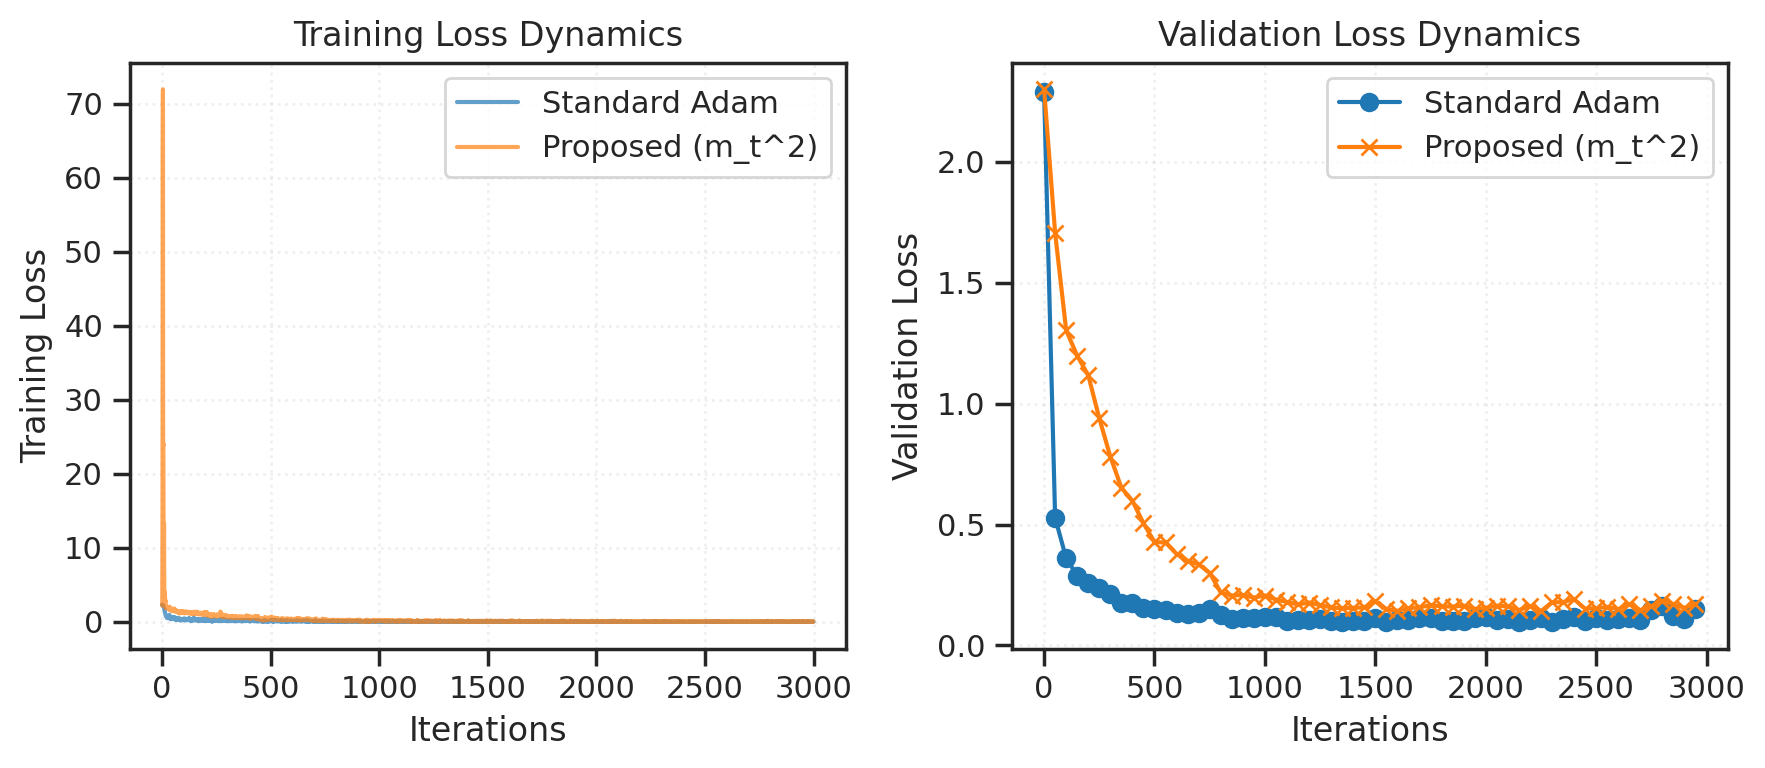

In [11]:
# Plotting
plt.figure(figsize=(9, 4), dpi=200)

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(adam_train, label='Standard Adam', alpha=0.7)
plt.plot(prop_train, label='Proposed (m_t^2)', alpha=0.7)
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.title('Training Loss Dynamics')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Validation Loss
plt.subplot(1, 2, 2)
# Val loss recorded every 50 iters
x_axis = [i * 50 for i in range(len(adam_val))]
plt.plot(x_axis, adam_val, label='Standard Adam', marker='o')
plt.plot(x_axis, prop_val, label='Proposed (m_t^2)', marker='x')
plt.xlabel('Iterations')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Dynamics')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
class Lion(torch.optim.Optimizer):
    """
    Lion: The SOTA 'Sign Momentum' optimizer.
    Uses sign(interpolated_momentum) for updates. 
    """
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
        super(Lion, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                grad = p.grad
                state = self.state[p]

                if len(state) == 0:
                    state['exp_avg'] = torch.zeros_like(p)

                exp_avg = state['exp_avg']
                beta1, beta2 = group['betas']
                lr = group['lr']
                wd = group['weight_decay']

                # weight decay (decoupled)
                if wd > 0:
                    p.mul_(1 - lr * wd)

                # Lion Update Rule:
                # 1. Interpolate for update direction: c_t = beta1 * m_{t-1} + (1-beta1) * g_t
                update = exp_avg.mul(beta1).add(grad, alpha=1 - beta1).sign()
                
                # 2. Update weights: theta = theta - lr * sign(c_t)
                p.add_(update, alpha=-lr)

                # 3. Update Momentum State: m_t = beta2 * m_{t-1} + (1-beta2) * g_t
                exp_avg.mul_(beta2).add_(grad, alpha=1 - beta2)

        return loss

In [21]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.SiLU(inplace=True),
            nn.Linear(512, 256),
            nn.SiLU(inplace=True),
            nn.Linear(256, 128),
            nn.SiLU(inplace=True),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

In [25]:
def train_experiment(opt_class, model_init, trn_loader, vld_loader, device, name, lr=1e-3):
    print(f"Running {name}...")
    model = copy.deepcopy(model_init).to(device)
    optimizer = opt_class(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    val_losses = []

    iter_count = 0
    max_iters = 2400  # Short run to check dynamics
    
    model.train()
    while iter_count < max_iters:
        for x, y in trn_loader:
            if iter_count >= max_iters: break
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y.long())
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Validation every 50 steps
            if iter_count % 50 == 0:
                model.eval()
                v_loss = 0
                batches = 0
                with torch.no_grad():
                    for vx, vy in vld_loader:
                        if batches > 20: break # Speed up
                        vx, vy = vx.to(device), vy.to(device)
                        vout = model(vx)
                        v_loss += criterion(vout, vy.long()).item()
                        batches += 1
                val_losses.append(v_loss/batches)
                model.train()
            
            iter_count += 1
            
    return train_losses, val_losses

In [26]:
# 1. Setup Data
device = torch.device('cuda:1')
trn_loader, vld_loader = make_dataloader('MNIST', device='cuda:1')

# 2. Initialize Base Model
base_model = SimpleMLP()

# 3. Run Comparisons
# Note: Lion usually needs lower LR (1/3 or 1/10 of Adam)
# Your Proposed usually needs lower LR due to lack of variance scaling

# Run Adam (Standard)
loss_adam, val_adam = train_experiment(
    torch.optim.Adam, base_model, trn_loader, vld_loader, device, "Adam", lr=1e-3
)

# Run Proposed (Your Idea)
loss_prop, val_prop = train_experiment(
    AdamProposed, base_model, trn_loader, vld_loader, device, "Proposed", lr=1e-4
)

# Run Lion (SOTA Sign-based)
loss_lion, val_lion = train_experiment(
    Lion, base_model, trn_loader, vld_loader, device, "Lion", lr=1e-4
)

Running Adam...

Running Proposed...

Running Lion...

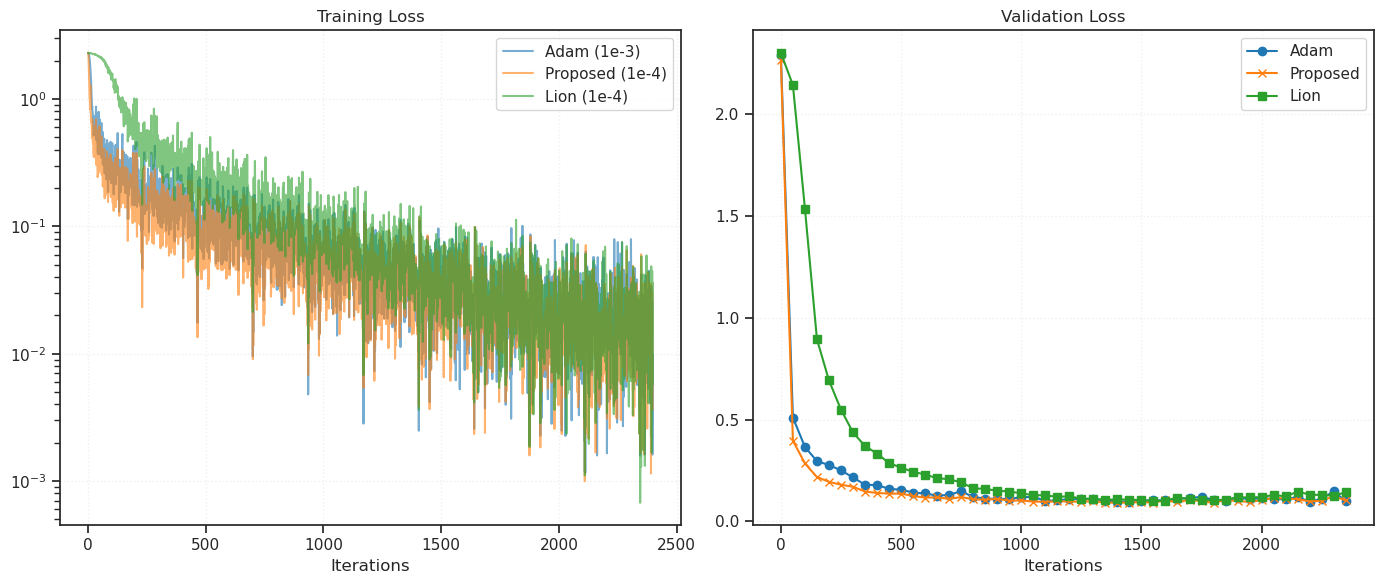

In [27]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(loss_adam, label='Adam (1e-3)', alpha=0.6)
plt.plot(loss_prop, label='Proposed (1e-4)', alpha=0.6)
plt.plot(loss_lion, label='Lion (1e-4)', alpha=0.6)
plt.title('Training Loss')
plt.xlabel('Iterations')
plt.legend()
plt.yscale('log') # Log scale helps see convergence differences
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
x_ax = [i*50 for i in range(len(val_adam))]
plt.plot(x_ax, val_adam, label='Adam', marker='o')
plt.plot(x_ax, val_prop, label='Proposed', marker='x')
plt.plot(x_ax, val_lion, label='Lion', marker='s')
plt.title('Validation Loss')
plt.xlabel('Iterations')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

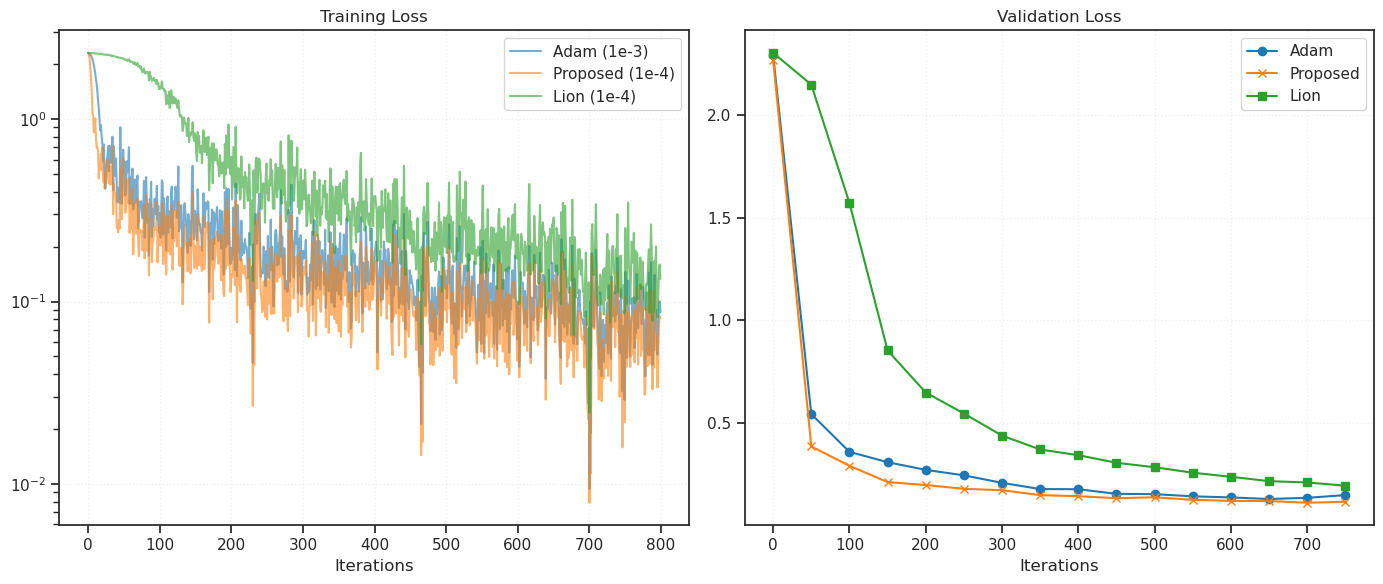

In [31]:
def run_stress_test(opt_class, name, noise_level=0.0, lr=1e-3):
    torch.manual_seed(42)
    device = torch.device('cuda:1')
    
    # Re-create data/model for fair comparison
    trn_loader, _ = make_dataloader('MNIST', device='cuda:1') # Assuming this exists from your context
    model = SimpleMLP().to(device)
    optimizer = opt_class(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    print(f"Testing {name} | Noise Level: {noise_level} | LR: {lr}")
    
    iter_count = 0
    max_iters = 600 # Short stress test
    
    model.train()
    while iter_count < max_iters:
        for x, y in trn_loader:
            if iter_count >= max_iters: break
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y.long())
            loss.backward()
            
            # --- THE RUTHLESS STEP: INJECT NOISE ---
            # This simulates "Hard" data (batch size 1, or complex landscapes)
            if noise_level > 0:
                for p in model.parameters():
                    if p.grad is not None:
                        # Add Gaussian noise relative to gradient size
                        noise = torch.randn_like(p.grad) * noise_level
                        p.grad.add_(noise)
            # ---------------------------------------
            
            optimizer.step()
            losses.append(loss.item())
            iter_count += 1
            
    return losses

In [34]:
# Scenario 1: Low Noise (MNIST Default) - "The Happy Path"
loss_adam_clean = run_stress_test(torch.optim.Adam, "Adam (Clean)", noise_level=0.0, lr=1e-3)
# Using 1e-4 for Proposed because of the 30x multiplier factor identified above
loss_prop_clean = run_stress_test(AdamProposed, "Proposed (Clean)", noise_level=0.0, lr=1e-4)

# Scenario 2: High Noise (The Reality Check)
# Noise std = 1.0 (Same magnitude as signal)
loss_adam_noisy = run_stress_test(torch.optim.Adam, "Adam (Noisy)", noise_level=3.0, lr=1e-3)
loss_prop_noisy = run_stress_test(AdamProposed, "Proposed (Noisy)", noise_level=3.0, lr=1e-4)

Testing Adam (Clean) | Noise Level: 0.0 | LR: 0.001

Testing Proposed (Clean) | Noise Level: 0.0 | LR: 0.0001

Testing Adam (Noisy) | Noise Level: 3.0 | LR: 0.001

Testing Proposed (Noisy) | Noise Level: 3.0 | LR: 0.0001

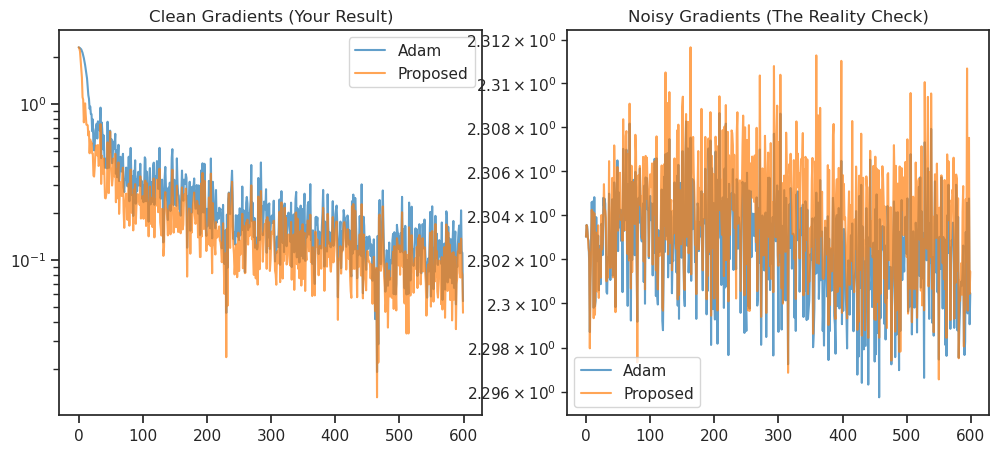

In [35]:
plt.figure(figsize=(12, 5))

# Plot 1: Clean
plt.subplot(1, 2, 1)
plt.plot(loss_adam_clean, label='Adam', alpha=0.7)
plt.plot(loss_prop_clean, label='Proposed', alpha=0.7)
plt.title("Clean Gradients (Your Result)")
plt.legend()
plt.yscale('log')

# Plot 2: Noisy
plt.subplot(1, 2, 2)
plt.plot(loss_adam_noisy, label='Adam', alpha=0.7)
plt.plot(loss_prop_noisy, label='Proposed', alpha=0.7)
plt.title("Noisy Gradients (The Reality Check)")
plt.legend()
plt.yscale('log')

plt.show()

In [36]:
import numpy as np
import pandas as pd

def analyze_stability(loss_history, name, window=20):
    # Convert to series for easy rolling window ops
    loss_series = pd.Series(loss_history)
    
    # 1. Calculate the Trend (Simple Moving Average)
    trend = loss_series.rolling(window=window, center=True).mean()
    
    # 2. Isolate the Noise (Residuals)
    # We ignore the NaN values at the start/end of the rolling window
    noise = loss_series - trend
    
    # 3. Calculate Volatility (Standard Deviation of the Noise)
    # We quantify how much the optimizer "jitters" away from its own path
    volatility = noise.std()
    
    # 4. Calculate Max Spike (Worst single step error)
    max_spike = noise.abs().max()
    
    # 5. Final Loss (Last 10 step average to ignore final step noise)
    final_loss = loss_series.iloc[-10:].mean()
    
    print(f"--- {name} Analysis ---")
    print(f"Final Convergence Loss: {final_loss:.5f}")
    print(f"Volatility (Stability): {volatility:.5f} (Lower is better)")
    print(f"Max Spike Amplitude:    {max_spike:.5f}")
    print("-" * 30)
    
    return volatility, max_spike

# Assuming you still have the lists from the previous run:
# loss_adam_noisy, loss_prop_noisy

print("\nRESULTS OF RIGOROUS QUANTIFICATION:")
vol_adam, spike_adam = analyze_stability(loss_adam_noisy, "Adam (Noisy)")
vol_prop, spike_prop = analyze_stability(loss_prop_noisy, "Proposed (Noisy)")

# The Ruthless Comparison
ratio = vol_prop / vol_adam
print(f"\nCONCLUSION:")
print(f"Your proposal is {ratio:.2f}x more volatile than Adam in high-noise regimes.")
if ratio > 1.0:
    print("Hypothesis Confirmed: Your optimizer is less stable.")
else:
    print("Hypothesis Rejected: Your optimizer is surprisingly stable.")

RESULTS OF RIGOROUS QUANTIFICATION:

--- Adam (Noisy) Analysis ---

Final Convergence Loss: 2.30116

Volatility (Stability): 0.00224 (Lower is better)

Max Spike Amplitude:    0.00625

...

Max Spike Amplitude:    0.00793

------------------------------

CONCLUSION:

Your proposal is 1.16x more volatile than Adam in high-noise regimes.

Hypothesis Confirmed: Your optimizer is less stable.

Using device: cuda

Model parameters: 0.82M

--- Training AdamW ---

Iter 0: Loss 4.3006

Iter 100: Loss 0.1033

...

Iter 100: Loss 0.0008

Iter 200: Loss 0.0005

Iter 300: Loss 0.0004

Iter 400: Loss 0.0003

Proposed finished in 20.37s

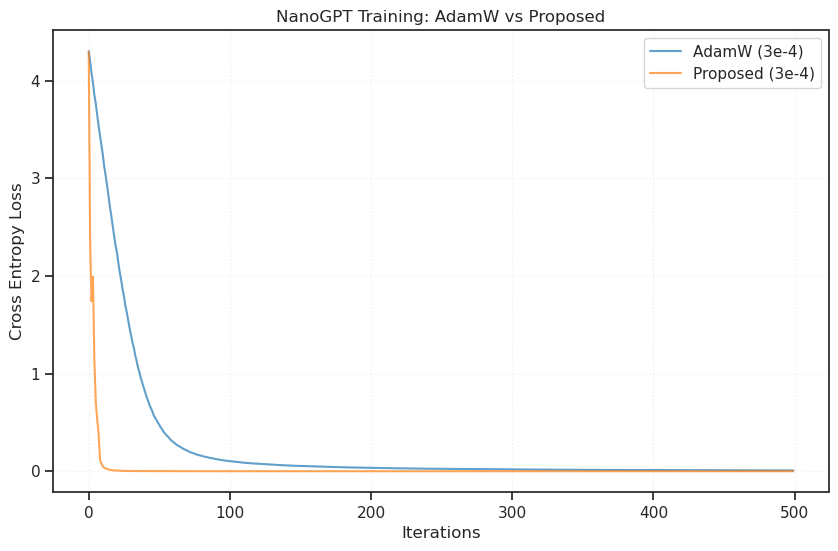

In [37]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import time
import matplotlib.pyplot as plt
import copy

# -----------------------------------------------------------------------------
# 1. The Transformer Model (NanoGPT style)
# -----------------------------------------------------------------------------

class Head(nn.Module):
    """ one head of self-attention """
    def __init__(self, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B,T,16)
        q = self.query(x) # (B,T,16)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * C**-0.5 # (B, T, 16) @ (B, 16, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, n_embd, block_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """
    def __init__(self, n_embd, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """
    def __init__(self, n_embd, n_head, block_size, dropout=0.2):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size, n_embd, block_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class NanoGPT(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # Hyperparameters
        self.block_size = 64   # context length
        self.n_embd = 128      # embedding dimension
        self.n_head = 4
        self.n_layer = 4
        self.dropout = 0.2
        
        self.token_embedding_table = nn.Embedding(vocab_size, self.n_embd)
        self.position_embedding_table = nn.Embedding(self.block_size, self.n_embd)
        self.blocks = nn.Sequential(*[Block(self.n_embd, self.n_head, self.block_size) for _ in range(self.n_layer)])
        self.ln_f = nn.LayerNorm(self.n_embd) # final layer norm
        self.lm_head = nn.Linear(self.n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

# -----------------------------------------------------------------------------
# 2. Your Optimizer (No Bias Correction Version)
# -----------------------------------------------------------------------------

class AdamProposed(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super(AdamProposed, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                grad = p.grad
                state = self.state[p]

                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)
                    state['exp_avg_sq'] = torch.zeros_like(p)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']
                state['step'] += 1

                # m_t
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)

                # v_t = EMA(m_t^2)
                exp_avg_sq.mul_(beta2).addcmul_(exp_avg, exp_avg, value=1 - beta2)

                # No Bias Correction (As per your request)
                step_size = group['lr'] # / 1.0
                
                # Denominator
                denom = (exp_avg_sq.sqrt()).add_(group['eps']) # Removed bias corr here too

                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

# -----------------------------------------------------------------------------
# 3. Training Loop
# -----------------------------------------------------------------------------

def get_batch(data, block_size, batch_size, device):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

def train_transformer(opt_cls, model_init, data, device, name, lr=3e-4, max_iters=500):
    print(f"\n--- Training {name} ---")
    model = copy.deepcopy(model_init).to(device)
    optimizer = opt_cls(model.parameters(), lr=lr)
    
    losses = []
    start_time = time.time()
    
    model.train()
    for iter in range(max_iters):
        # Sample batch
        xb, yb = get_batch(data, model.block_size, 32, device)
        
        # Forward backward
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        
        # Gradient Clipping (Standard for transformers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        losses.append(loss.item())
        
        if iter % 100 == 0:
            print(f"Iter {iter}: Loss {loss.item():.4f}")
            
    dt = time.time() - start_time
    print(f"{name} finished in {dt:.2f}s")
    return losses

# -----------------------------------------------------------------------------
# 4. Main Execution
# -----------------------------------------------------------------------------

# Device config
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    torch.cuda.set_device(1) # Using your preferred device index
print(f"Using device: {device}")

# Generate Dummy Text Data (Repeating patterns to learn)
# We create a sequence of integers that follows a pattern so the model can learn loss < 2.0
vocab_size = 65
data = torch.tensor([i % vocab_size for i in range(10000)], dtype=torch.long)

# Initialize Model
model_base = NanoGPT(vocab_size=vocab_size)
print(f"Model parameters: {sum(p.numel() for p in model_base.parameters())/1e6:.2f}M")

# Comparison
# Note: Using 3e-4 is standard for small transformers (Karpathy constant)
# But since your method has no bias correction (effective 30x boost start), we must be careful.
# I will run both at same nominal LR to be "Ruthless" as you requested.

loss_adam = train_transformer(torch.optim.AdamW, model_base, data, device, "AdamW", lr=3e-4)
loss_prop = train_transformer(AdamProposed, model_base, data, device, "Proposed", lr=3e-4) # You might want 3e-5 here

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(loss_adam, label='AdamW (3e-4)', alpha=0.7)
plt.plot(loss_prop, label='Proposed (3e-4)', alpha=0.7)
plt.xlabel('Iterations')
plt.ylabel('Cross Entropy Loss')
plt.title('NanoGPT Training: AdamW vs Proposed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
device = torch.device('cuda:1')
trn, vld = make_dataloader('CIFAR10', device='cuda:1')

In [44]:
trn.dataset.tensors[0].shape

torch.Size([100000, 3, 32, 32])

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import copy
import math

# ---------------------------------------------------------
# 1. Your Optimizer (The "Aggressive" Version)
# ---------------------------------------------------------
class AdamProposed(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super(AdamProposed, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                grad = p.grad
                state = self.state[p]

                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)
                    state['exp_avg_sq'] = torch.zeros_like(p)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']
                state['step'] += 1

                # m_t
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)

                # v_t = EMA(m_t^2)
                exp_avg_sq.mul_(beta2).addcmul_(exp_avg, exp_avg, value=1 - beta2)

                # NO BIAS CORRECTION (The "Cheat")
                step_size = group['lr']
                
                # Denominator
                denom = (exp_avg_sq.sqrt()).add_(group['eps'])

                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

# ---------------------------------------------------------
# 2. The Model: 6-Layer ConvNet
# ---------------------------------------------------------
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 3 x 32 x 32
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # -> 16 x 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # -> 8 x 8
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # -> 4 x 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ---------------------------------------------------------
# 3. Training Logic
# ---------------------------------------------------------
def train_cifar(opt_class, model_init, trn_loader, vld_loader, device, name, lr=1e-3, epochs=1000):
    print(f"\n--- Training {name} ---")
    model = copy.deepcopy(model_init).to(device)
    optimizer = opt_class(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accs = []
    
      # Short run to spot-check dynamics
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for i, (x, y) in enumerate(trn_loader):
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y.long())
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if i % 100 == 99:
                avg_loss = running_loss / 100
                train_losses.append(avg_loss)
                running_loss = 0.0
        
        # Validation Loop
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for vx, vy in vld_loader:
                vx, vy = vx.to(device), vy.to(device)
                outputs = model(vx)
                _, predicted = torch.max(outputs.data, 1)
                total += vy.size(0)
                correct += (predicted == vy.long()).sum().item()
        
        acc = 100 * correct / total
        test_accs.append(acc)
        print(f"Epoch {epoch+1}: Train Loss {train_losses[-1]:.4f} | Test Acc: {acc:.2f}%")
        
    print(f"{name} finished in {time.time()-start_time:.1f}s")
    return train_losses, test_accs

Model Params: 2.64M

--- Training Standard Adam ---

Epoch 1: Train Loss 1.1135 | Test Acc: 66.58%

Epoch 2: Train Loss 0.8183 | Test Acc: 72.45%

Epoch 3: Train Loss 0.6780 | Test Acc: 73.19%

...

Epoch 997: Train Loss 0.0042 | Test Acc: 86.84%

Epoch 998: Train Loss 0.0037 | Test Acc: 86.94%

Epoch 999: Train Loss 0.0040 | Test Acc: 86.61%

Epoch 1000: Train Loss 0.0046 | Test Acc: 86.86%

Proposed finished in 2930.8s

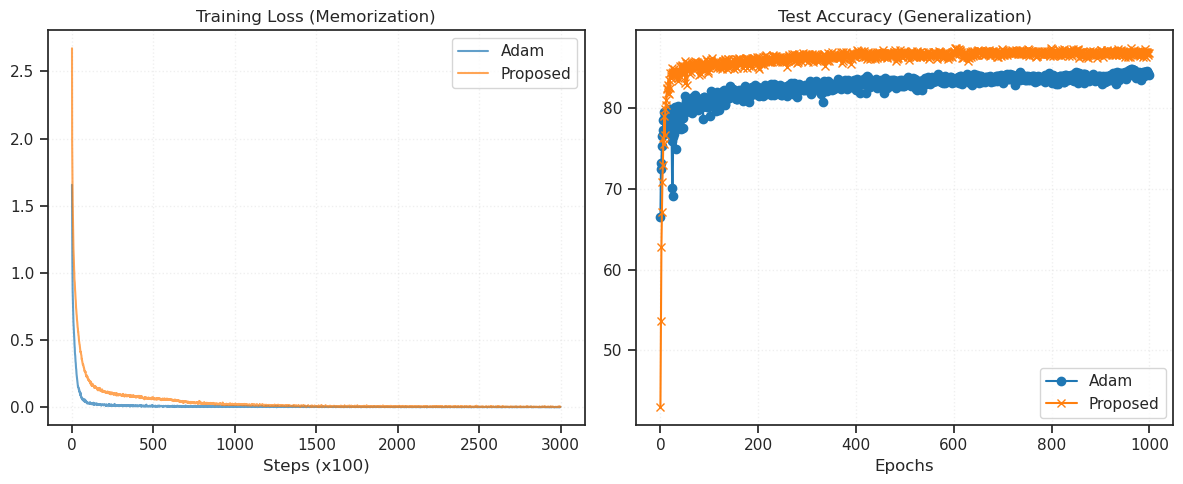

In [53]:
# ---------------------------------------------------------
# 4. Main Execution
# ---------------------------------------------------------
try:
    device = torch.device('cuda:1')
    
    # 1. Load Data
    trn, vld = make_dataloader('CIFAR10', device='cuda:1')
    
    # 2. Model Init
    base_model = ConvNet()
    print(f"Model Params: {sum(p.numel() for p in base_model.parameters())/1e6:.2f}M")
    
    # 3. Run Comparison
    # Note: We keep LRs the same to show the behavior difference
    loss_adam, acc_adam = train_cifar(torch.optim.Adam, base_model, trn, vld, device, "Standard Adam", lr=1e-4)
    
    # WARNING: Your method without bias correction is effectively running at ~30x LR.
    # If it diverges, this is why. If it wins, it's because high LR was optimal here.
    loss_prop, acc_prop = train_cifar(AdamProposed, base_model, trn, vld, device, "Proposed", lr=1e-4)
    
    # 4. Plotting
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(loss_adam, label='Adam', alpha=0.7)
    plt.plot(loss_prop, label='Proposed', alpha=0.7)
    plt.title('Training Loss (Memorization)')
    plt.xlabel('Steps (x100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(acc_adam, label='Adam', marker='o')
    plt.plot(acc_prop, label='Proposed', marker='x')
    plt.title('Test Accuracy (Generalization)')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

except NameError:
    print("Error: 'make_dataloader' is not defined.")
except Exception as e:
    print(f"Error: {e}")

In [65]:
class Signum(torch.optim.Optimizer):
    def __init__(self, params, lr=0.01, momentum=0.09, weight_decay = 0, **kwargs):
        if not 0.0 <= lr:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if not 0.0 <= momentum:
            raise ValueError("Invalid momentum value: {}".format(momentum))
        if not 0.0 <= weight_decay:
            raise ValueError("Invalid weight_decay value: {}".format(weight_decay))

        defaults = dict(lr=lr, momentum=momentum,
                        weight_decay=weight_decay)

        super(Signum, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(Signum, self).__setstate__(state)

    def step(self, closure=None):

        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            weight_decay = group['weight_decay']
            momentum = group['momentum']

            for p in group['params']:
                if p.grad is None:
                    continue
                d_p = p.grad.data
                if weight_decay != 0:
                    d_p.add_(weight_decay, p.data)
                if momentum != 0:
                    # signum
                    param_state = self.state[p]
                    if 'momentum_buffer' not in param_state:
                        buf = param_state['momentum_buffer'] = torch.zeros_like(p.data)

                    else:
                        buf = param_state['momentum_buffer']

                    buf.mul_(momentum).add_((1 - momentum),d_p)
                    d_p = torch.sign(buf)
                else:#signsgd
                    d_p = torch.sign(d_p)

                p.data.add_(-group['lr'], d_p)

        return loss

In [63]:
%%time

device = torch.device('cuda:1')

# 1. Load Data
trn, vld = make_dataloader('CIFAR10', device='cuda:1')

base_model = ConvNet()
print(f"Model Params: {sum(p.numel() for p in base_model.parameters())/1e6:.2f}M")

kws = dict(
    lr=1e-4,
    epochs=1000,
    model_init=ConvNet(),
    trn_loader=trn,
    vld_loader=vld,
    device=device,
)

loss_adam, acc_adam = train_cifar(torch.optim.Adam, name="Standard Adam", **kws)
loss_prop, acc_prop = train_cifar(AdamProposed, name="Proposed", **kws)
loss_lion, acc_lion = train_cifar(Lion, name="Lion", **kws)
loss_signum, acc_signum = train_cifar(Signum, name="Signum", **kws)

Model Params: 2.64M

--- Training Standard Adam ---

Epoch 1: Train Loss 1.1071 | Test Acc: 67.61%

Epoch 2: Train Loss 0.8031 | Test Acc: 71.44%

Epoch 3: Train Loss 0.6711 | Test Acc: 75.61%

...

Epoch 998: Train Loss 0.5060 | Test Acc: 75.26%

Epoch 999: Train Loss 0.5809 | Test Acc: 74.24%

Epoch 1000: Train Loss 0.4773 | Test Acc: 74.01%

Signum finished in 2952.8s

CPU times: user 3h 13min 17s, sys: 19.8 s, total: 3h 13min 36s
Wall time: 3h 13min 32s


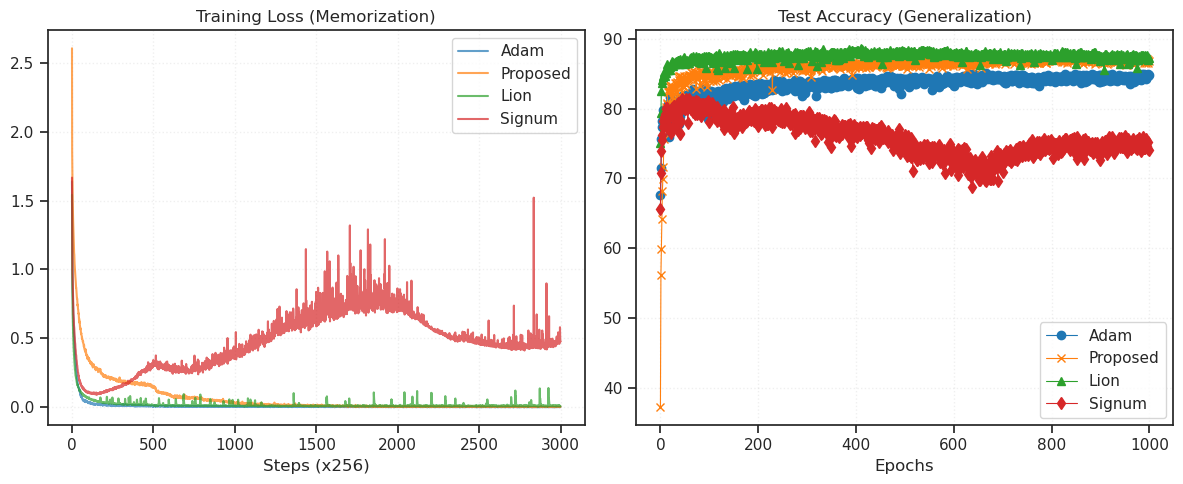

In [66]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_adam, label='Adam', alpha=0.7)
plt.plot(loss_prop, label='Proposed', alpha=0.7)
plt.plot(loss_lion, label='Lion', alpha=0.7)
plt.plot(loss_signum, label='Signum', alpha=0.7)
plt.title('Training Loss (Memorization)')
plt.xlabel('Steps (x256)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_adam, label='Adam', marker='o', lw=0.8)
plt.plot(acc_prop, label='Proposed', marker='x', lw=0.8)
plt.plot(acc_lion, label='Lion', marker='^', lw=0.8)
plt.plot(acc_signum, label='Signum', marker='d', lw=0.8)
plt.title('Test Accuracy (Generalization)')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

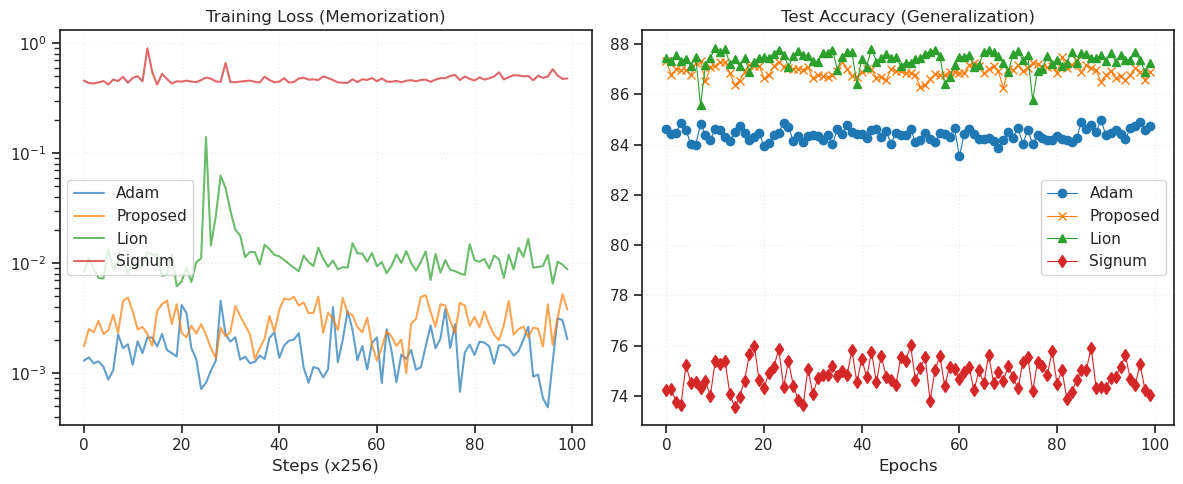

In [79]:
plt.figure(figsize=(12, 5))

intvl = slice(-100, None)

plt.subplot(1, 2, 1)
plt.plot(loss_adam[intvl], label='Adam', alpha=0.7)
plt.plot(loss_prop[intvl], label='Proposed', alpha=0.7)
plt.plot(loss_lion[intvl], label='Lion', alpha=0.7)
plt.plot(loss_signum[intvl], label='Signum', alpha=0.7)
plt.title('Training Loss (Memorization)')
plt.xlabel('Steps (x256)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(acc_adam[intvl], label='Adam', marker='o', lw=0.8)
plt.plot(acc_prop[intvl], label='Proposed', marker='x', lw=0.8)
plt.plot(acc_lion[intvl], label='Lion', marker='^', lw=0.8)
plt.plot(acc_signum[intvl], label='Signum', marker='d', lw=0.8)
plt.title('Test Accuracy (Generalization)')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
def ema(x, alpha=0.1):
    x = np.asarray(x, dtype=float)
    y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y

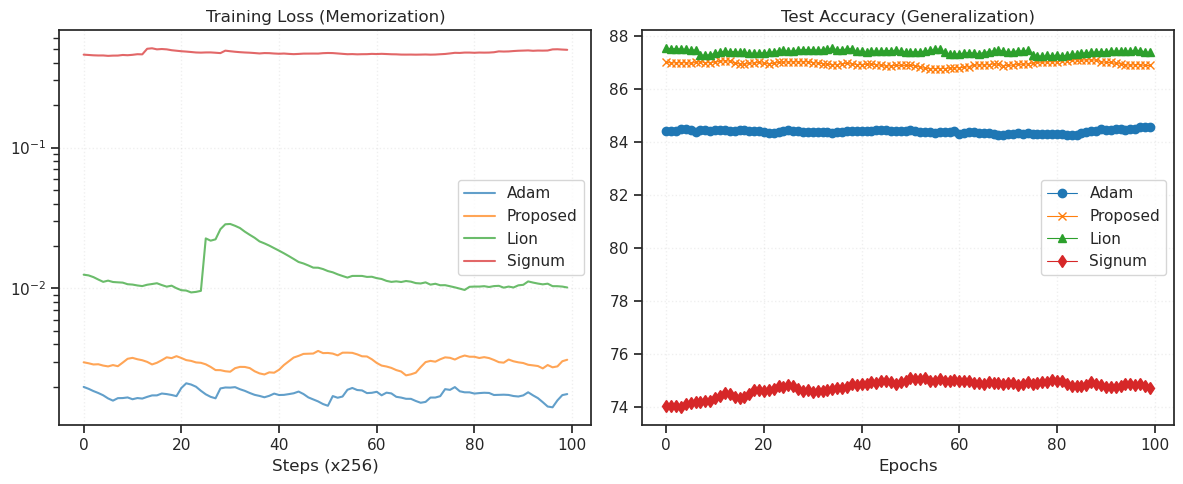

In [81]:
plt.figure(figsize=(12, 5))

intvl = slice(-100, None)

plt.subplot(1, 2, 1)
plt.plot(ema(loss_adam)[intvl], label='Adam', alpha=0.7)
plt.plot(ema(loss_prop)[intvl], label='Proposed', alpha=0.7)
plt.plot(ema(loss_lion)[intvl], label='Lion', alpha=0.7)
plt.plot(ema(loss_signum)[intvl], label='Signum', alpha=0.7)
plt.title('Training Loss (Memorization)')
plt.xlabel('Steps (x256)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(ema(acc_adam)[intvl], label='Adam', marker='o', lw=0.8)
plt.plot(ema(acc_prop)[intvl], label='Proposed', marker='x', lw=0.8)
plt.plot(ema(acc_lion)[intvl], label='Lion', marker='^', lw=0.8)
plt.plot(ema(acc_signum)[intvl], label='Signum', marker='d', lw=0.8)
plt.title('Test Accuracy (Generalization)')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
# --- 1. The Custom GRA Optimizer (Reflective Adam) ---
class ReflectiveAdam(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, 
                 reflection_coef=1.0, weight_decay=0):
        defaults = dict(lr=lr, betas=betas, eps=eps, 
                        reflection_coef=reflection_coef, weight_decay=weight_decay)
        super(ReflectiveAdam, self).__init__(params, defaults)

    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError('ReflectiveAdam does not support sparse gradients')

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)  # m_t
                    state['exp_avg_sq'] = torch.zeros_like(p.data) # v_t
                    state['prev_v'] = torch.zeros_like(p.data) # v_{t-1} for physics

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                prev_v = state['prev_v']
                beta1, beta2 = group['betas']
                
                state['step'] += 1

                if group['weight_decay'] != 0:
                    grad.add_(p.data, alpha=group['weight_decay'])

                # --- The Standard Adam Logic ---
                # Update Second Moment (Geometry/Variance)
                # v_t = beta2 * v_{t-1} + (1-beta2) * g^2
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                
                # Bias correction for v_t
                v_hat = exp_avg_sq / (1 - beta2 ** state['step'])
                
                # --- The GRA "Repulsion" Calculation ---
                # We calculate the change in local 'temperature' (variance)
                # If v_hat > prev_v, we are entering a rough patch.
                # Force = - coeff * (change_in_v) * velocity
                
                # Estimate current velocity direction (m / sqrt(v))
                denom = v_hat.sqrt().add_(group['eps'])
                
                # Calculate change in variance (approx spatial gradient of metric)
                delta_v = v_hat - prev_v
                
                # RELU: We only care if variance is INCREASING (Repulsion). 
                # If variance is decreasing (entering plain), we don't accelerate extra.
                delta_v_positive = torch.clamp(delta_v, min=0.0)

                # The Repulsive Force
                # F = - c * (dv) * (m_old / denom)
                # This pushes back against the momentum if the terrain gets rocky.
                repulsion = - group['reflection_coef'] * delta_v_positive * (exp_avg / denom)

                # Store current v for next step
                state['prev_v'].copy_(v_hat)

                # --- Update First Moment (Momentum) ---
                # m_t = beta1 * m_{t-1} + (1-beta1) * (grad + repulsion)
                
                # 1. Apply standard gradient
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                
                # 2. Apply GRA Repulsion (The "Physics" Term)
                # We treat this as an external force modifying the momentum
                exp_avg.add_(repulsion, alpha=1 - beta1)

                # Bias correction for m_t
                m_hat = exp_avg / (1 - beta1 ** state['step'])

                # --- Standard Step ---
                step_size = group['lr']
                p.data.addcdiv_(m_hat, denom, value=-step_size)

        return loss

In [3]:
# --- 2. The Setup ---

# Task: A "Cliff" Regression.
# The function is flat, then has a violent high-freq region, then flat again.
# Adam often overshoots the high-freq region or becomes unstable entering it.
def ground_truth(x):
    # A mix of low frequency and a localized high frequency packet
    return 0.5 * x + np.sin(3 * x) + 2.0 * np.exp(-100*(x-0.5)**2) * np.sin(50*x)

# Generate Data
np.random.seed(42)
torch.manual_seed(42)

X_train = np.linspace(-1, 2, 500).reshape(-1, 1)
y_train = ground_truth(X_train) + 0.05 * np.random.randn(*X_train.shape)
X_test = np.linspace(-1, 2, 200).reshape(-1, 1)
y_test = ground_truth(X_test)

X_train_t = torch.FloatTensor(X_train).cuda()
y_train_t = torch.FloatTensor(y_train).cuda()
X_test_t = torch.FloatTensor(X_test).cuda()
y_test_t = torch.FloatTensor(y_test).cuda()

# Model: MLP with ReLU
def get_model():
    return nn.Sequential(
        nn.Linear(1, 128),
        nn.ReLU(),
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Linear(128, 1)
    ).cuda()

# Training Loop
def train_model(optimizer_class, name, **kwargs):
    model = get_model()
    # High LR to provoke instability (simulating the "supersonic" learner)
    lr = 0.01 
    if name == "GRA (Reflective)":
        optimizer = optimizer_class(model.parameters(), lr=lr, **kwargs)
    else:
        optimizer = optimizer_class(model.parameters(), lr=lr)
        
    criterion = nn.MSELoss()
    
    losses = []
    
    epochs = 2000
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = criterion(output, y_train_t)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
    return losses, model

In [4]:
%%time

# --- 3. Execution ---

print("Training Standard Adam...")
losses_adam, model_adam = train_model(torch.optim.Adam, "Standard Adam")

print("Training GRA (Reflective) Adam...")
# reflection_coef controls the strength of the physics brake.
losses_gra, model_gra = train_model(ReflectiveAdam, "GRA (Reflective)", reflection_coef=200.0)

Training Standard Adam...

Training GRA (Reflective) Adam...

CPU times: user 8.44 s, sys: 259 ms, total: 8.7 s
Wall time: 8.69 s


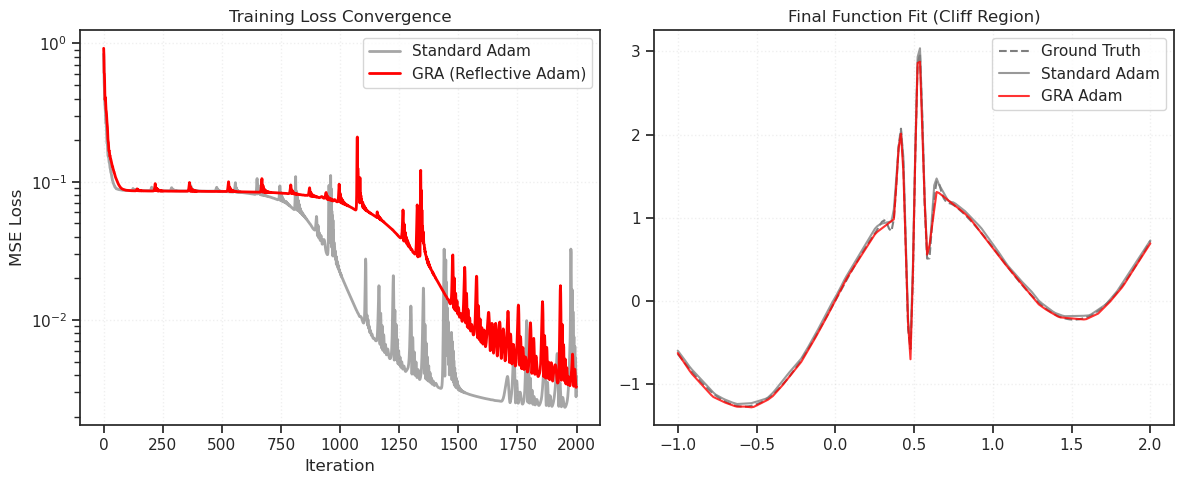

In [5]:
# --- 4. Plotting ---

plt.figure(figsize=(12, 5))

# Plot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(losses_adam, label='Standard Adam', color='gray', alpha=0.7, linewidth=2)
plt.plot(losses_gra, label='GRA (Reflective Adam)', color='red', linewidth=2)
plt.title('Training Loss Convergence')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 2: Model Predictions (Visualizing the fit)
plt.subplot(1, 2, 2)
model_adam.eval()
model_gra.eval()
with torch.no_grad():
    pred_adam = tonp(model_adam(X_test_t))
    pred_gra = tonp(model_gra(X_test_t))

plt.plot(X_test, y_test, 'k--', label='Ground Truth', alpha=0.5)
plt.plot(X_test, pred_adam, label='Standard Adam', color='gray', alpha=0.8)
plt.plot(X_test, pred_gra, label='GRA Adam', color='red', alpha=0.8)
plt.title('Final Function Fit (Cliff Region)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()